## Loading dataset

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vicsuperman/prediction-of-music-genre")

print("Path to dataset files:", path)

Path to dataset files: /Users/supathat/.cache/kagglehub/datasets/vicsuperman/prediction-of-music-genre/versions/1


In [2]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import StackingClassifier



In [3]:

# List files in the downloaded dataset
files = os.listdir(path)
print("Dataset files:", files)

Dataset files: ['music_genre.csv']


In [4]:
#Load data
df = pd.read_csv(os.path.join(path, "music_genre.csv"))

## Data preprocessing

##### Take a look at the dataframe

In [5]:
df.head()

,instance_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,obtained_date,valence,music_genre
0,32894.0,Röyksopp,Röyksopp's Night Out,27.0,0.00468,0.652,-1.0,0.941,0.79200,A#,0.115,-5.201,Minor,0.0748,100.889,4-Apr,0.759,Electronic
1,46652.0,Thievery Corporation,The Shining Path,31.0,0.01270,0.622,218293.0,0.890,0.95000,D,0.124,-7.043,Minor,0.0300,115.00200000000001,4-Apr,0.531,Electronic
2,30097.0,Dillon Francis,Hurricane,28.0,0.00306,0.620,215613.0,0.755,0.01180,G#,0.534,-4.617,Major,0.0345,127.994,4-Apr,0.333,Electronic
3,62177.0,Dubloadz,Nitro,34.0,0.02540,0.774,166875.0,0.700,0.00253,C#,0.157,-4.498,Major,0.2390,128.014,4-Apr,0.270,Electronic
4,24907.0,What So Not,Divide & Conquer,32.0,0.00465,0.638,222369.0,0.587,0.90900,F#,0.157,-6.266,Major,0.0413,145.036,4-Apr,0.323,Electronic


In [6]:
df.shape

(50005, 18)

#### Remove rows where data is incomplete

In [7]:
bad_values = ['', ' ', '?' ,-1 ,'-1']
rows_to_drop = df.isna() | df.isin(bad_values)
df = df[~rows_to_drop.any(axis=1)]
df.shape

df['tempo'] = pd.to_numeric(df['tempo'], errors='coerce')
df = df.dropna(subset=['tempo']).reset_index(drop=True)

### Remove duplicated rows

Removing rows which have all columns the same, meaning duplicate data.

In [8]:
duplicate_rows = df.duplicated()
if duplicate_rows.sum() > 0:
    print("\nDuplicate rows:")
    print(df[duplicate_rows])
    df = df.drop_duplicates().reset_index(drop=True)
df.shape

(40560, 18)

For the models, there should not be two songs with the same artist name and track name with different non-numeric values, for example, key, genre or mode. If they have same non-numeric values but different numeric values, then the average numeric values can be used.

In [9]:
key_columns = ['artist_name', 'track_name']
target_col = 'music_genre'
subset_duplicates = df.duplicated(subset=key_columns)
print(f"Duplicates based on {key_columns}: {subset_duplicates.sum()}")
print(df[df.duplicated(subset=key_columns, keep=False)].sort_values(key_columns))

Duplicates based on ['artist_name', 'track_name']: 2593
       instance_id       artist_name                  track_name  popularity  \
2608       83947.0               !!!  Even When The Water's Cold        61.0   
14147      51893.0               !!!  Even When The Water's Cold        52.0   
23341      81298.0       $uicideBoy$                    2nd Hand        74.0   
38741      53674.0       $uicideBoy$                    2nd Hand        74.0   
21742      55684.0       $uicideBoy$      Do You Believe In God?        65.0   
...            ...               ...                         ...         ...   
39390      26618.0  nothing,nowhere.         Clarity In Kerosene        54.0   
23274      25949.0  nothing,nowhere.       I'm Sorry, I'm Trying        60.0   
37929      40229.0  nothing,nowhere.       I'm Sorry, I'm Trying        60.0   
21697      54743.0  nothing,nowhere.                     Letdown        61.0   
40251      66770.0  nothing,nowhere.                     Letdown

In [10]:
non_numeric_cols = df.select_dtypes(exclude='number').columns.difference(key_columns)

conflicting_non_numeric_mask = (
    df.groupby(key_columns)[non_numeric_cols]
      .transform(lambda col: col.nunique(dropna=False) > 1)
      .any(axis=1)
)
df = df[~conflicting_non_numeric_mask].reset_index(drop=True)
df.shape

(35480, 18)

Need to check for outliers, to make sure they are dropped. For example, if a song has duration in the negatives or is too long.

In [11]:
print(df['duration_ms'].nlargest(10).to_string(index=False))


4497994.0
4276000.0
3195440.0
2764934.0
2294000.0
2019293.0
1935787.0
1872653.0
1778440.0
1617333.0


In [12]:
print(df['duration_ms'].nsmallest(10).to_string(index=False))


15509.0
16316.0
19693.0
20096.0
22750.0
24000.0
26293.0
26717.0
27179.0
28947.0


These values are within acceptable ranges, so there is no need to drop them.

## Visualising the dataset

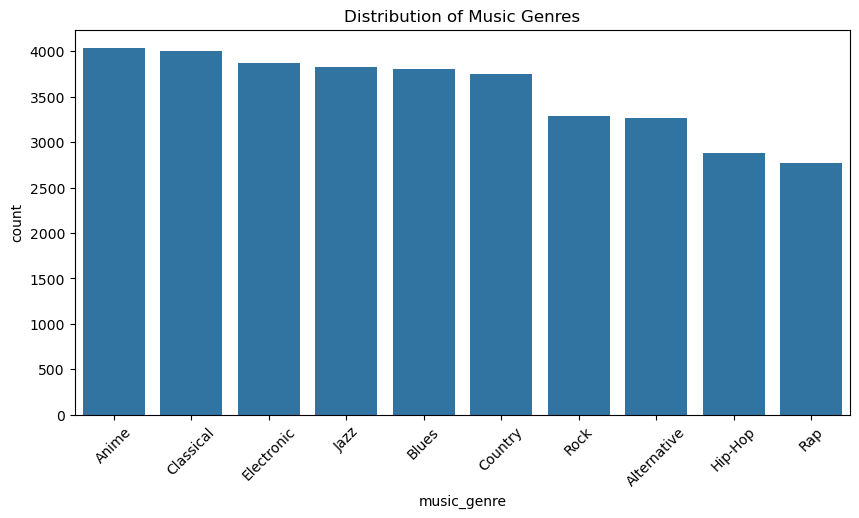

In [13]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='music_genre', order=df['music_genre'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Distribution of Music Genres')
plt.show()

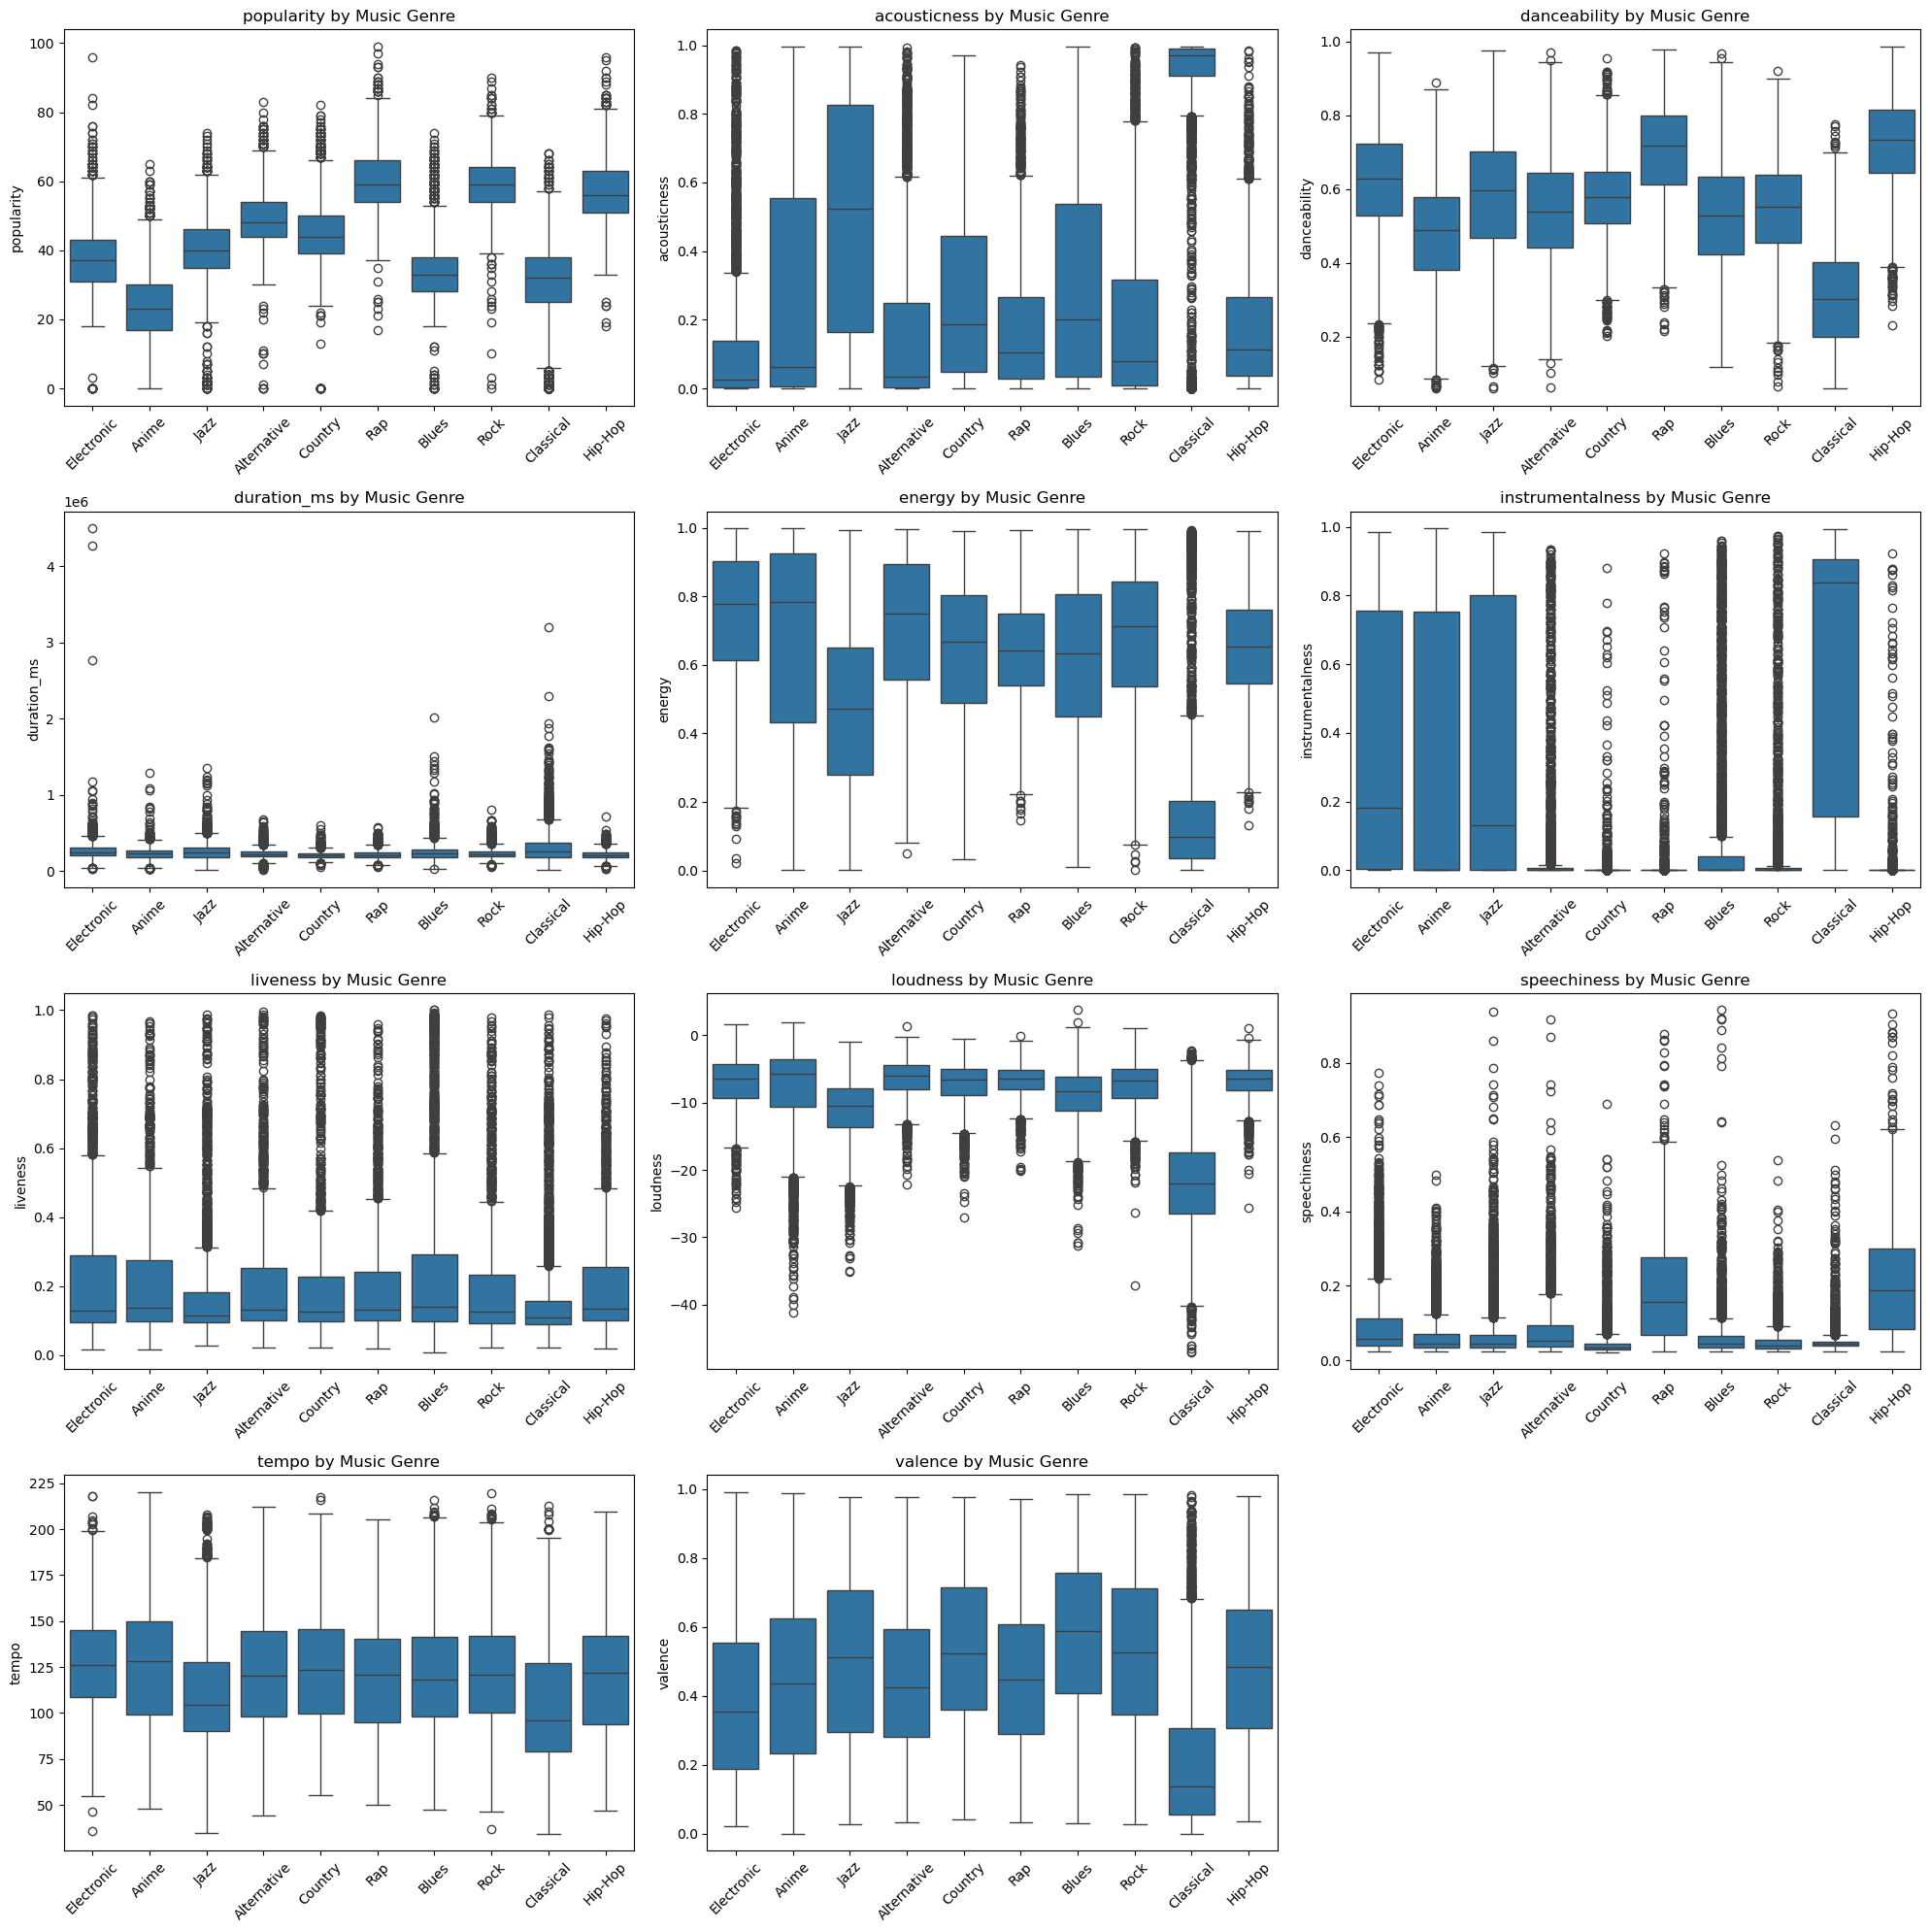

In [14]:

features = ['popularity', 'acousticness', 'danceability', 'duration_ms',
            'energy', 'instrumentalness', 'liveness', 'loudness',
            'speechiness', 'tempo', 'valence']

fig, axes = plt.subplots(4, 3, figsize=(20, 20))

axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=df,
        x='music_genre',
        y=feature,
        ax=axes[i]
    )
    axes[i].set_title(f'{feature} by Music Genre')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(feature)

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

A correlation heat map to show how each feature correlates to another.

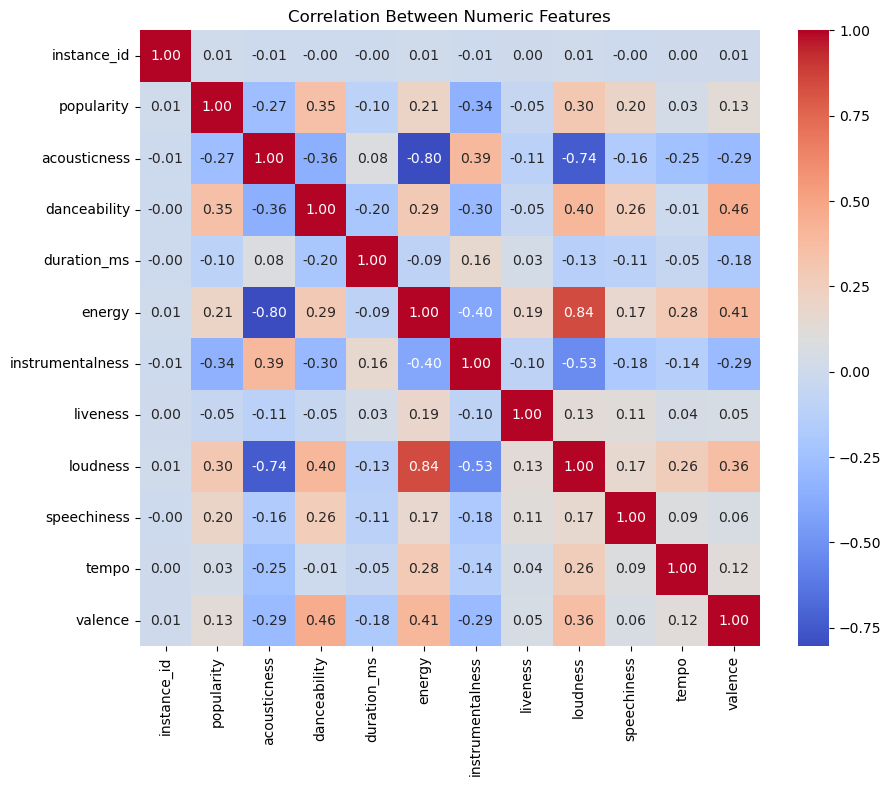

In [15]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numeric Features')
plt.show()

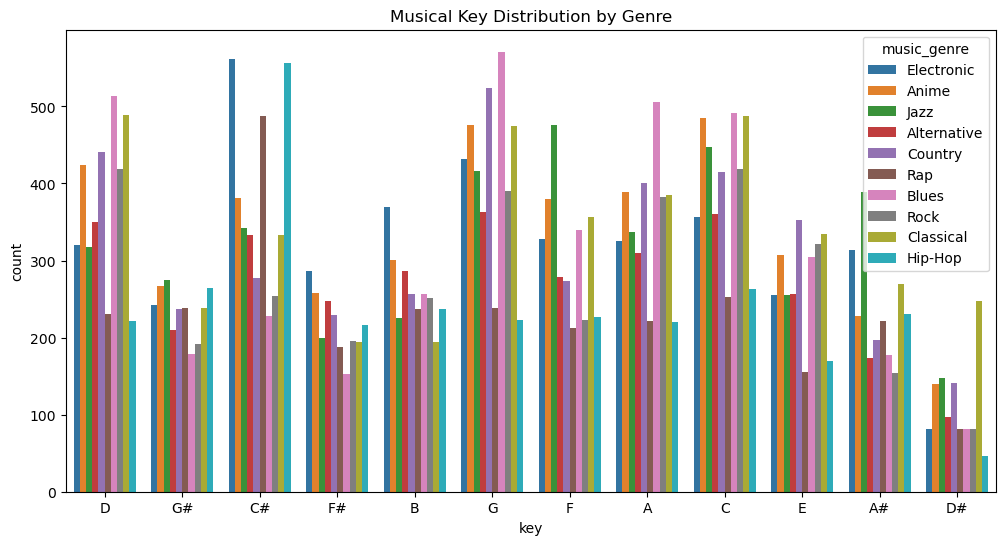

In [16]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='key', hue='music_genre')
plt.title('Musical Key Distribution by Genre')
plt.show()

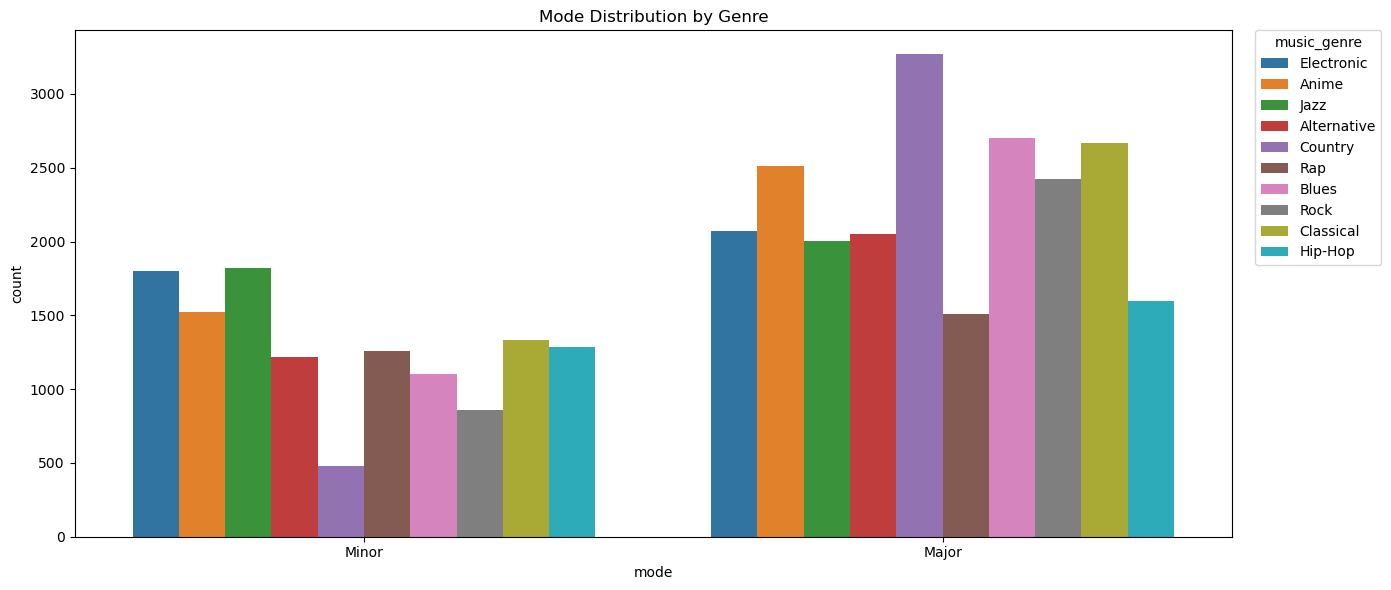

In [17]:
plt.figure(figsize=(14, 6))

ax = sns.countplot(data=df, x='mode', hue='music_genre')

plt.title('Mode Distribution by Genre')
plt.xlabel('mode')
plt.ylabel('count')

plt.legend(
    title='music_genre',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.show()


## Feature Engineering

After removing duplicate and incomplete rows, we need to select features to train the model with. This section goes through encoding non-numerical values such as key and mode. First, the columns that do not provide any useful information should be dropped.

New interaction features were created to capture relationships between audio properties. For example, energy and danceability together may help distinguish high-energy dance genres from genres that are energetic but less dance-oriented. Tempo was also grouped into categories to provide a simpler rhythmic feature.


In [18]:
df['duration_min'] = df['duration_ms'] / 60000
df = df.drop(columns=['duration_ms'])
df['energy_danceability'] = df['energy'] * df['danceability']
df['energy_valence'] = df['energy'] * df['valence']
df['acoustic_instrumental'] = df['acousticness'] * df['instrumentalness']
df['tempo'] = pd.to_numeric(df['tempo'], errors='coerce')
df = df.dropna(subset=['tempo']).reset_index(drop=True)
df['tempo_category'] = pd.cut(
    df['tempo'],
    bins=[0, 90, 120, 160, float('inf')],
    labels=['slow', 'medium', 'fast', 'very_fast']
)

In [19]:
target_col = 'music_genre'
drop_cols = [target_col,'artist_name','track_name','obtained_date','instance_id']
categorical_cols = ['key', 'mode', 'tempo_category']
# mode is binary so drop='first' removes it to one column, meaning 1 for minor and 0 for major
encoder = OneHotEncoder(drop = 'first',sparse_output=False)
one_hot_encoded = encoder.fit_transform(df[categorical_cols])
encoded_cols = encoder.get_feature_names_out(categorical_cols)
encoded_df = pd.DataFrame(
    one_hot_encoded,
    columns=encoded_cols,
    index=df.index
)
df_encoded = pd.concat([df, encoded_df], axis=1)
df_encoded = df_encoded.drop(categorical_cols, axis=1)
X = df_encoded.drop(columns=drop_cols)
y = df_encoded[target_col]

In [20]:
X.head()

,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,...,key_D#,key_E,key_F,key_F#,key_G,key_G#,mode_Minor,tempo_category_medium,tempo_category_slow,tempo_category_very_fast
0,31.0,0.01270,0.622,0.890,0.950000,0.124,-7.043,0.0300,115.002,0.531,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,28.0,0.00306,0.620,0.755,0.011800,0.534,-4.617,0.0345,127.994,0.333,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,34.0,0.02540,0.774,0.700,0.002530,0.157,-4.498,0.2390,128.014,0.270,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,32.0,0.00465,0.638,0.587,0.909000,0.157,-6.266,0.0413,145.036,0.323,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,46.0,0.02890,0.572,0.803,0.000008,0.106,-4.294,0.3510,149.995,0.230,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Mutual Information Scores for Features:
                     Feature  MI Score
0                 popularity  0.615074
13     acoustic_instrumental  0.324213
1               acousticness  0.299234
6                   loudness  0.297897
11       energy_danceability  0.296441
3                     energy  0.288549
4           instrumentalness  0.280084
2               danceability  0.247710
12            energy_valence  0.205490
7                speechiness  0.203759
8                      tempo  0.152375
10              duration_min  0.117144
9                    valence  0.115889
25                mode_Minor  0.026277
27       tempo_category_slow  0.023990
5                   liveness  0.023242
17                    key_C#  0.008286
28  tempo_category_very_fast  0.005027
26     tempo_category_medium  0.004955
14                    key_A#  0.002441
19                    key_D#  0.002346
18                     key_D  0.002181
23                     key_G  0.001921
15                     k

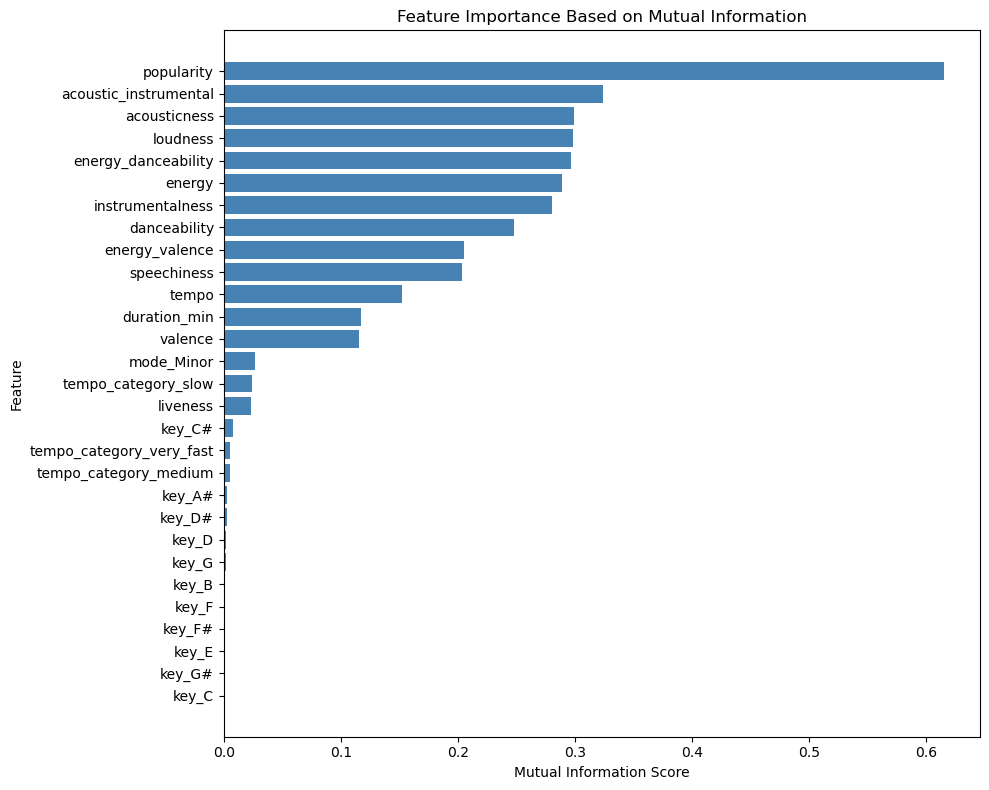

In [21]:

discrete_features = X.columns.str.startswith(('key_', 'mode_','tempo_category'))

mi_scores = mutual_info_classif(
    X,
    y,
    discrete_features=discrete_features,
    random_state=42
)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
})

mi_df = mi_df.sort_values(by='MI Score', ascending=False)

print("Mutual Information Scores for Features:")
print(mi_df)

plt.figure(figsize=(10, 8))
plt.barh(mi_df['Feature'], mi_df['MI Score'], color='steelblue')

plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Feature Importance Based on Mutual Information")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Popularity was retained because it may contain useful genre-related information. Some genres may have different popularity patterns on streaming platforms, so this feature could help improve classification performance. However, popularity is not an audio characteristic, so it may reflect listener behavior or platform trends rather than the sound of the track. Later on, we will model with probability and without, to answer if only audio properties can be used to identify genres.


A univariate filter method was used for feature selection. Each feature was ranked independently using mutual information with the target genre. This method was chosen because it is classifier-independent, allowing the same selected feature subset to be used across all models. Mutual information was preferred because it can capture non-linear relationships between individual features and the multiclass target.


A correlation heatmap for redundancy checks whether some features are giving almost the same information.



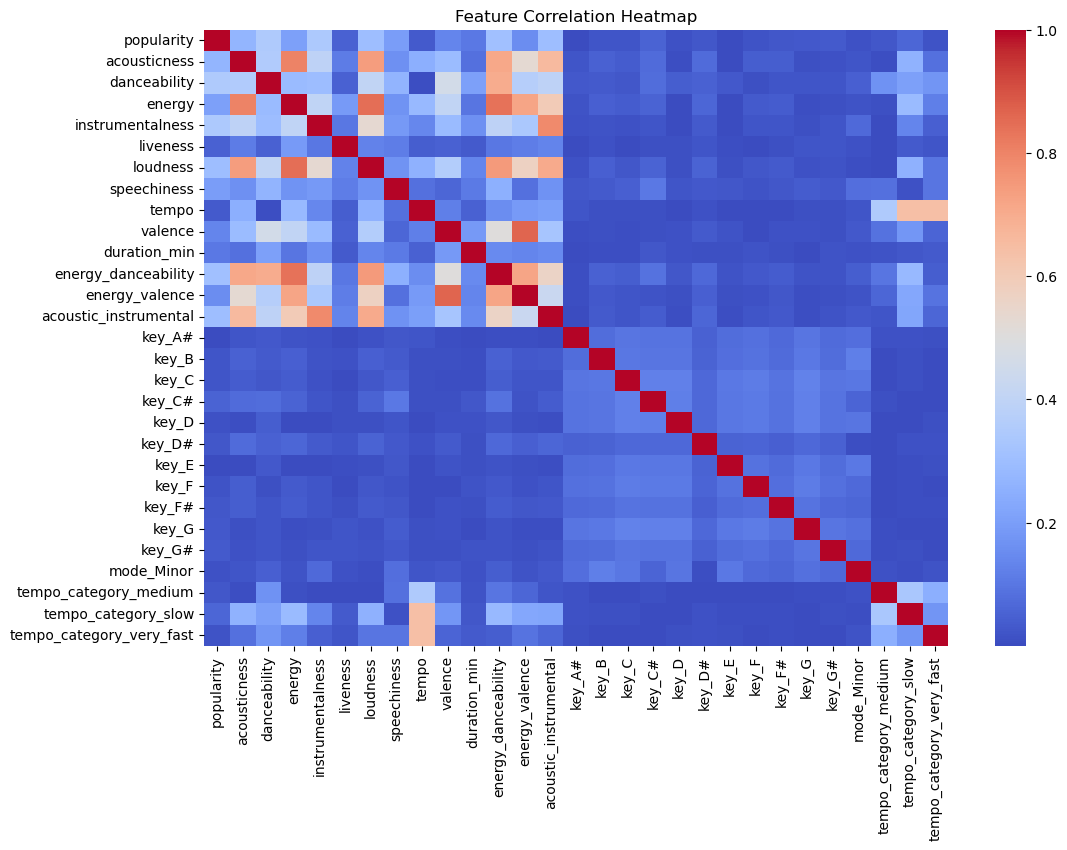

In [22]:
corr_matrix = X.corr().abs()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## Feature selection with KNN

KNN was used as a simple validation model to choose the number of selected features. The resulting feature subset was then shared across all models for fair comparison.


The data was split into training and test sets using stratified sampling so that the genre distribution remained similar in both sets.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Implementing cross-validation on the training set to select features.

In [ ]:
cross_validation = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)
max_features = X_train.shape[1]

k_options = [5, 10, 15, 20, 25, max_features]
k_options = sorted(set(k for k in k_options if k <= max_features))


In [25]:
feature_selection_results = []

for k in k_options:
    fold_scores = []

    for train_index, validation_index in cross_validation.split(X_train, y_train):
        X_fold_train = X_train.iloc[train_index]
        X_fold_validation = X_train.iloc[validation_index]

        y_fold_train = y_train.iloc[train_index]
        y_fold_validation = y_train.iloc[validation_index]

        discrete_feature_mask = X_fold_train.columns.str.startswith(
            ("key_", "mode_", "tempo_category_")
        )

        selector = SelectKBest(
            score_func=lambda X_data, y_data: mutual_info_classif(
                X_data,
                y_data,
                discrete_features=discrete_feature_mask,
                random_state=42
            ),
            k=k
        )

        X_fold_train_selected = selector.fit_transform(
            X_fold_train,
            y_fold_train
        )

        X_fold_validation_selected = selector.transform(
            X_fold_validation
        )

        scaler = StandardScaler()
        X_fold_train_scaled = scaler.fit_transform(X_fold_train_selected)
        X_fold_validation_scaled = scaler.transform(X_fold_validation_selected)

        model = KNeighborsClassifier(n_neighbors=5)
        model.fit(X_fold_train_scaled, y_fold_train)

        y_fold_pred = model.predict(X_fold_validation_scaled)

        fold_score = f1_score(
            y_fold_validation,
            y_fold_pred,
            average="macro",
            zero_division=0
        )

        fold_scores.append(fold_score)

    feature_selection_results.append({
        "k": k,
        "Mean CV Macro F1": np.mean(fold_scores),
        "Std CV Macro F1": np.std(fold_scores)
    })

feature_selection_results_df = pd.DataFrame(feature_selection_results)
feature_selection_results_df


,k,Mean CV Macro F1,Std CV Macro F1
0,10,0.503599,0.003682
1,15,0.505415,0.002473
2,20,0.475998,0.004992
3,25,0.443416,0.001465
4,29,0.423376,0.002757


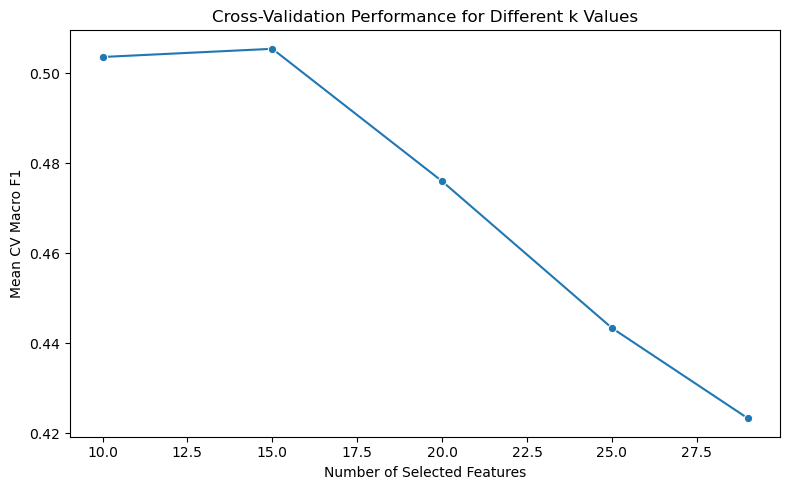

Best k: 15.0


In [26]:
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=feature_selection_results_df,
    x="k",
    y="Mean CV Macro F1",
    marker="o"
)
plt.title("Cross-Validation Performance for Different k Values")
plt.xlabel("Number of Selected Features")
plt.ylabel("Mean CV Macro F1")
plt.tight_layout()
plt.show()

best_k = feature_selection_results_df.sort_values(
    by="Mean CV Macro F1",
    ascending=False
).iloc[0]["k"]

print("Best k:", best_k)


In [27]:
discrete_feature_mask = X_train.columns.str.startswith(
    ("key_", "mode_", "tempo_category_")
)

final_selector = SelectKBest(
    score_func=lambda X_data, y_data: mutual_info_classif(
        X_data,
        y_data,
        discrete_features=discrete_feature_mask,
        random_state=42
    ),
    k=int(best_k)
)

X_train_selected = final_selector.fit_transform(X_train, y_train)
X_test_selected = final_selector.transform(X_test)

selected_features = X_train.columns[
    final_selector.get_support()
].tolist()

print("Selected features:")
for feature in selected_features:
    print("-", feature)


Selected features:
- popularity
- acousticness
- danceability
- energy
- instrumentalness
- liveness
- loudness
- speechiness
- tempo
- valence
- duration_min
- energy_danceability
- energy_valence
- acoustic_instrumental
- mode_Minor


## Data Modelling

Genre is non-numeric, so the modelling methods should use classification. Here, we compare KNN classification, Decision Tree, Naive Bayes. Hyperparameters are tuned with stratified cross-validation on the training data.


In [28]:
models = {
    "KNN": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        "params": {
            "model__n_neighbors": [3,5,7,15, 19, 21, 23, 25, 27, 29, 31, 35, 41]
        }
    },

    "Naive Bayes": {
        "pipeline": Pipeline([
            ("model", GaussianNB())
        ]),
        "params": {
            "model__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
        }
    },

    "Decision Tree": {
        "pipeline": Pipeline([
            ("model", DecisionTreeClassifier(random_state=42))
        ]),
        "params": {
            "model__max_depth": [3, 5, 7, 10, 12, 15, 20, None]
        }
    }
}


In [29]:
hyperparameter_results = []
conf_matrices = {}
best_models = {}

for name, config in models.items():
    print(f"\nTuning {name}")

    grid = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["params"],
        scoring="f1_macro",
        cv=cross_validation,
        n_jobs=1
    )

    grid.fit(X_train_selected, y_train)

    cv_results = pd.DataFrame(grid.cv_results_)

    param_cols = [
        col for col in cv_results.columns
        if col.startswith("param_")
    ]

    param_col = param_cols[0]
    hyperparameter_name = param_col.replace("param_model__", "")

    for value, score in zip(cv_results[param_col], cv_results["mean_test_score"]):
        hyperparameter_results.append({
            "Model": name,
            "Hyperparameter": hyperparameter_name,
            "Value": str(value),
            "Mean CV Macro F1": score
        })

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_selected)

    best_models[name] = best_model
    conf_matrices[name] = confusion_matrix(y_test, y_pred)

    print("Best parameters:", grid.best_params_)
    print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("Test Macro F1:", round(f1_score(y_test, y_pred, average="macro", zero_division=0), 4))



Tuning KNN
Best parameters: {'model__n_neighbors': 25}
Test Accuracy: 0.5455
Test Macro F1: 0.5342

Tuning Naive Bayes
Best parameters: {'model__var_smoothing': 0.0001}
Test Accuracy: 0.4494
Test Macro F1: 0.4382

Tuning Decision Tree
Best parameters: {'model__max_depth': 10}
Test Accuracy: 0.5364
Test Macro F1: 0.526


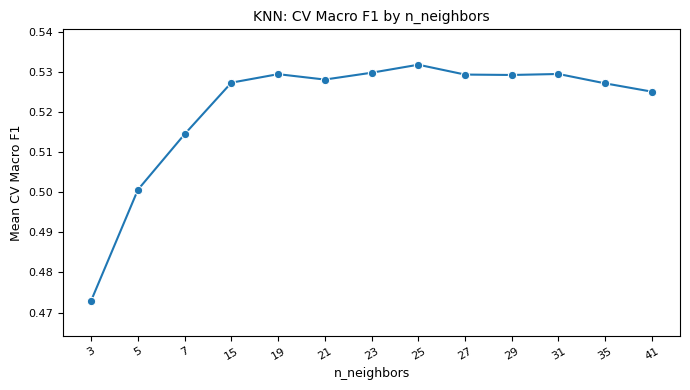

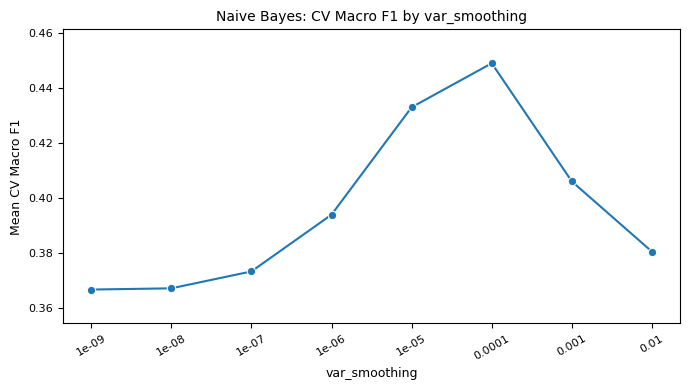

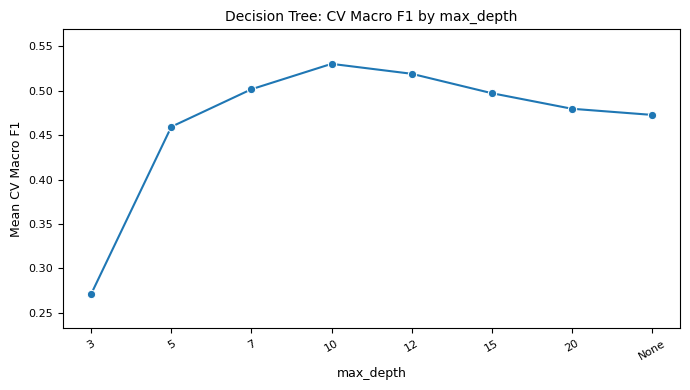

In [30]:
hyperparameter_results_df = pd.DataFrame(hyperparameter_results)

for model_name in hyperparameter_results_df["Model"].unique():
    model_data = hyperparameter_results_df[
        hyperparameter_results_df["Model"] == model_name
    ].copy()

    hyperparameter = model_data["Hyperparameter"].iloc[0]

    model_data["Value Order"] = range(len(model_data))

    y_min = model_data["Mean CV Macro F1"].min()
    y_max = model_data["Mean CV Macro F1"].max()
    padding = (y_max - y_min) * 0.15

    if padding == 0:
        padding = 0.01

    plt.figure(figsize=(7,4))
    sns.lineplot(
        data=model_data,
        x="Value Order",
        y="Mean CV Macro F1",
        marker="o"
    )

    plt.xticks(
        ticks=model_data["Value Order"],
        labels=model_data["Value"],
        rotation=30,
        fontsize=8
    )

    plt.yticks(fontsize=8)

    plt.ylim(
        max(0, y_min - padding),
        min(1, y_max + padding)
    )

    plt.title(
        f"{model_name}: CV Macro F1 by {hyperparameter}",
        fontsize=10
    )
    plt.xlabel(hyperparameter, fontsize=9)
    plt.ylabel("Mean CV Macro F1", fontsize=9)
    plt.tight_layout()
    plt.show()


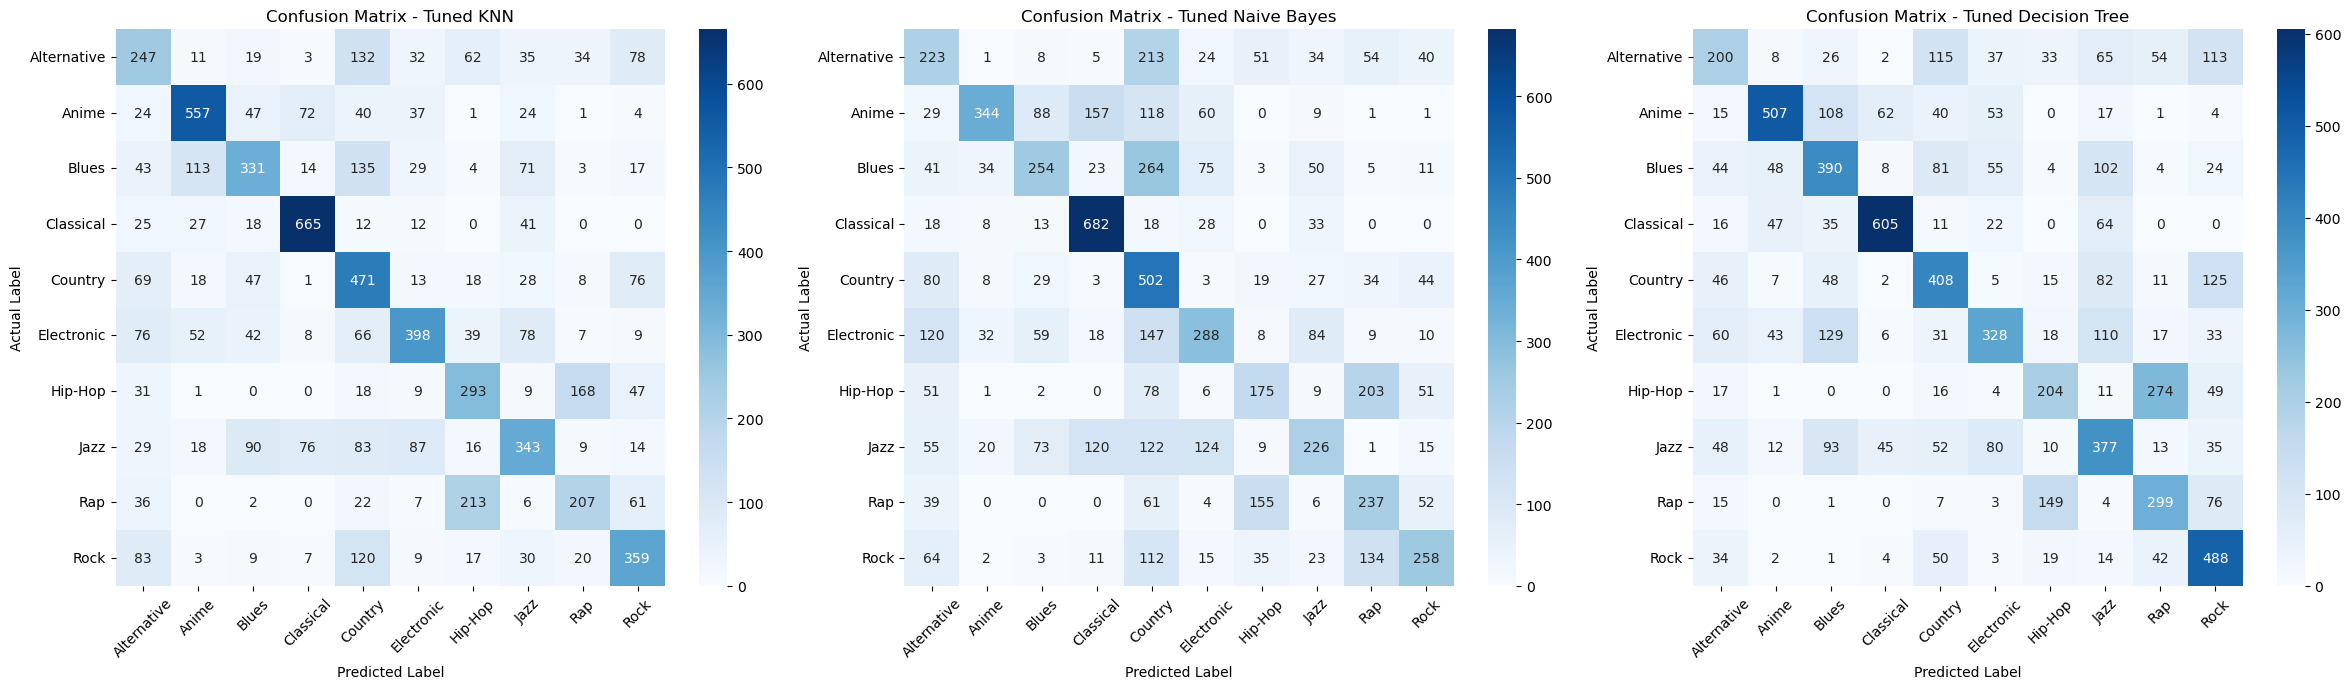

In [31]:
conf_matrices[name] = confusion_matrix(y_test, y_pred)
class_names = sorted(y_test.unique())

fig, axes = plt.subplots(1, len(conf_matrices), figsize=(24, 7))

for ax, (name, matrix) in zip(axes, conf_matrices.items()):
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=class_names,
        yticklabels=class_names
    )

    ax.set_title(f"Confusion Matrix - Tuned {name}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()


#### Neural Network

A Multi-Layer Perceptron (MLP) was used as the neural network model. MLP is suitable for this multiclass classification task because it can learn non-linear relationships between the selected audio features and music genre labels. The selected features were standardised before training because neural networks are sensitive to feature scale.


Hyperparameter tuning for hidden layers

In [32]:
hidden_layer_options = [
    (25,),
    (50,),
    (75,),
    (100,),
    (125,),
    (150,)
]


mlp_results = []

for hidden_layers in hidden_layer_options:
    fold_scores = []

    for train_index, validation_index in cross_validation.split(X_train_selected, y_train):
        X_fold_train = X_train_selected[train_index]
        X_fold_validation = X_train_selected[validation_index]


        y_fold_train = y_train.iloc[train_index]
        y_fold_validation = y_train.iloc[validation_index]

        scaler = StandardScaler()
        X_fold_train_scaled = scaler.fit_transform(X_fold_train)
        X_fold_validation_scaled = scaler.transform(X_fold_validation)

        mlp = MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            max_iter=500,
            random_state=42
        )

        mlp.fit(X_fold_train_scaled, y_fold_train)

        y_fold_pred = mlp.predict(X_fold_validation_scaled)

        fold_score = f1_score(
            y_fold_validation,
            y_fold_pred,
            average="macro",
            zero_division=0
        )

        fold_scores.append(fold_score)

    mlp_results.append({
        "hidden_layer_sizes": hidden_layers,
        "Mean CV Macro F1": np.mean(fold_scores),
        "Std CV Macro F1": np.std(fold_scores)
    })

mlp_results_df = pd.DataFrame(mlp_results)
mlp_results_df


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,hidden_layer_sizes,Mean CV Macro F1,Std CV Macro F1
0,"(25,)",0.587585,0.005168
1,"(50,)",0.594220,0.001949
2,"(75,)",0.594556,0.002666
3,"(100,)",0.592187,0.000789
4,"(125,)",0.592474,0.001755
5,"(150,)",0.587240,0.001456


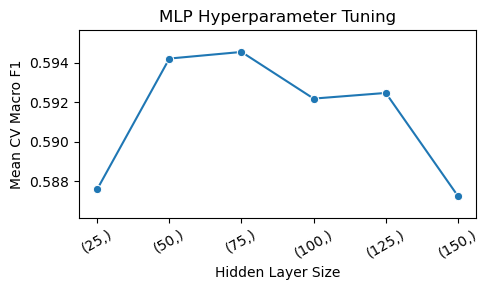

In [33]:
plot_df = mlp_results_df.copy()
plot_df["hidden_layer_sizes"] = plot_df["hidden_layer_sizes"].astype(str)

y_min = plot_df["Mean CV Macro F1"].min()
y_max = plot_df["Mean CV Macro F1"].max()
padding = (y_max - y_min) * 0.15

if padding == 0:
    padding = 0.01

plt.figure(figsize=(5, 3))

sns.lineplot(
    data=plot_df,
    x="hidden_layer_sizes",
    y="Mean CV Macro F1",
    marker="o"
)

plt.ylim(
    max(0, y_min - padding),
    min(1, y_max + padding)
)

plt.title("MLP Hyperparameter Tuning")
plt.xlabel("Hidden Layer Size")
plt.ylabel("Mean CV Macro F1")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [34]:
best_hidden_layers = mlp_results_df.sort_values(
    by="Mean CV Macro F1",
    ascending=False
).iloc[0]["hidden_layer_sizes"]

print("Best hidden layer size:", best_hidden_layers)


Best hidden layer size: (75,)


In [35]:
scaler = StandardScaler()

X_train_mlp = scaler.fit_transform(X_train_selected)
X_test_mlp = scaler.transform(X_test_selected)

mlp = MLPClassifier(
    hidden_layer_sizes=best_hidden_layers,
    max_iter=500,
    random_state=42
)

mlp.fit(X_train_mlp, y_train)

y_pred_mlp = mlp.predict(X_test_mlp)
print("MLP Accuracy:", round(accuracy_score(y_test, y_pred_mlp), 4))
print("MLP Macro F1:", round(f1_score(y_test, y_pred_mlp, average="macro", zero_division=0), 4))
print(classification_report(y_test, y_pred_mlp, zero_division=0))



MLP Accuracy: 0.6118
MLP Macro F1: 0.5986
              precision    recall  f1-score   support

 Alternative       0.46      0.39      0.42       653
       Anime       0.77      0.77      0.77       807
       Blues       0.60      0.56      0.58       760
   Classical       0.84      0.84      0.84       800
     Country       0.57      0.62      0.60       749
  Electronic       0.67      0.62      0.64       775
     Hip-Hop       0.47      0.51      0.49       576
        Jazz       0.59      0.51      0.55       765
         Rap       0.48      0.46      0.47       554
        Rock       0.55      0.74      0.63       657

    accuracy                           0.61      7096
   macro avg       0.60      0.60      0.60      7096
weighted avg       0.61      0.61      0.61      7096



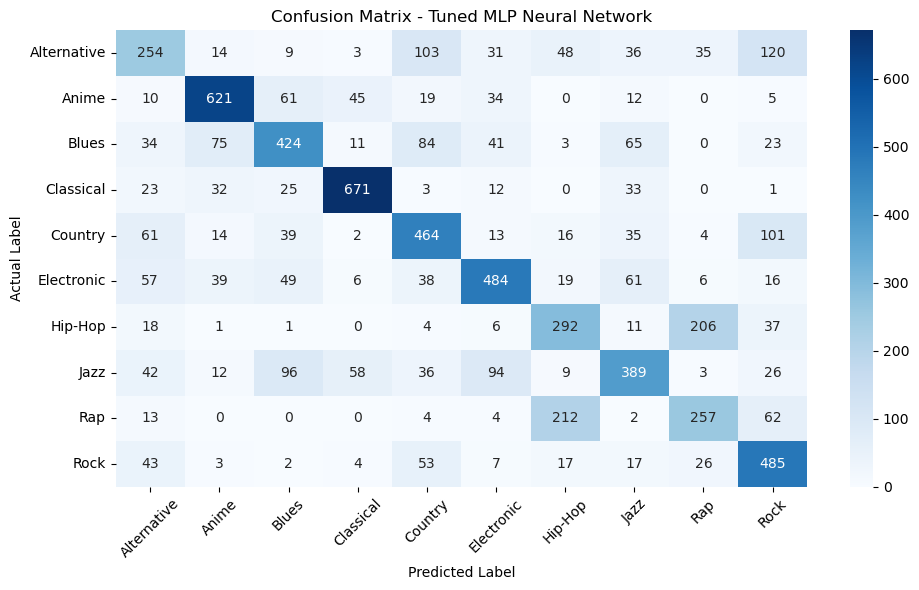

In [36]:
class_names = sorted(y_test.unique())

mlp_conf_matrix = confusion_matrix(
    y_test,
    y_pred_mlp,
    labels=class_names
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    mlp_conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Tuned MLP Neural Network")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


#### Ensemble Methods

In [37]:

# ---------------------------
# Stacking Ensemble with Cross-Validation
# ---------------------------

stacking_base_models = [
    ("KNN", Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=25))
    ])),

    ("Naive Bayes", GaussianNB(var_smoothing=0.0001)),

    ("Decision Tree", DecisionTreeClassifier(max_depth=10, random_state=42))
]

stacking_model = StackingClassifier(
    estimators=stacking_base_models,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    stack_method="predict_proba",
    cv=cross_validation,
    n_jobs=1
)

# Tune one hyperparameter for the stacking model
stacking_params = {
    "final_estimator__C": [0.01, 0.1, 1, 10, 100]
}

stacking_grid = GridSearchCV(
    estimator=stacking_model,
    param_grid=stacking_params,
    scoring="f1_macro",
    cv=cross_validation,
    n_jobs=1
)

stacking_grid.fit(X_train_selected, y_train)

best_stacking_model = stacking_grid.best_estimator_
y_pred_stack = best_stacking_model.predict(X_test_selected)

print("Best Stacking Parameters:", stacking_grid.best_params_)
print("CV Macro F1:", round(stacking_grid.best_score_, 4))
print("Test Accuracy:", round(accuracy_score(y_test, y_pred_stack), 4))
print("Test Macro F1:", round(f1_score(y_test, y_pred_stack, average="macro", zero_division=0), 4))
print(classification_report(y_test, y_pred_stack, zero_division=0))


Best Stacking Parameters: {'final_estimator__C': 10}
CV Macro F1: 0.5775
Test Accuracy: 0.5833
Test Macro F1: 0.5731
              precision    recall  f1-score   support

 Alternative       0.41      0.41      0.41       653
       Anime       0.73      0.72      0.73       807
       Blues       0.57      0.53      0.55       760
   Classical       0.83      0.81      0.82       800
     Country       0.56      0.57      0.57       749
  Electronic       0.64      0.56      0.60       775
     Hip-Hop       0.47      0.48      0.47       576
        Jazz       0.51      0.51      0.51       765
         Rap       0.47      0.45      0.46       554
        Rock       0.56      0.70      0.62       657

    accuracy                           0.58      7096
   macro avg       0.57      0.57      0.57      7096
weighted avg       0.59      0.58      0.58      7096



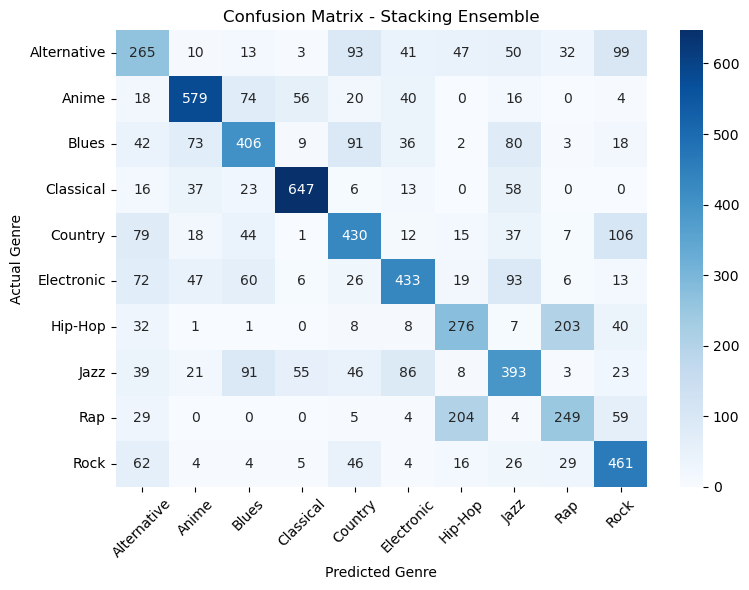

In [38]:
stacking_conf_matrix = confusion_matrix(y_test, y_pred_stack)

plt.figure(figsize=(8, 6))
sns.heatmap(
    stacking_conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.title("Confusion Matrix - Stacking Ensemble")
plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
